In [1]:
# Setup and imports
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set project root
_root = Path.cwd()
while not (_root / 'scripts' / 'config.py').exists():
    if _root == _root.parent:
        raise RuntimeError("Cannot find project root - launch Jupyter from the project directory")
    _root = _root.parent
project_root = _root
os.chdir(project_root)
sys.path.insert(0, str(project_root / "scripts"))

print(f"Working directory: {os.getcwd()}")

# Import config module and set population FIRST
import config as cfg
cfg.set_population_config("sea_jpt_cn")

# Now create aliases (pointing to updated config)
PATHS = cfg.PATHS
SITUATIONAL_FILTERS = cfg.SITUATIONAL_FILTERS
POPULATIONS = cfg.POPULATIONS

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import subprocess

# Statistical imports
from scipy.stats import chi2_contingency, entropy
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import fdrcorrection

# Project imports
from utils import count_variants

print("All imports successful!")

Working directory: /home/ibmelab/Projects/AISNP-Research
All imports successful!


## Step 1: Load Filtered Data from Step 02

In [2]:
# Input: LD-pruned pfile from step 02
INPUT_PFILE = str(PATHS.PLINK_LD_PRUNED)
SAMPLES_CSV = str(PATHS.EAS_SAMPLES_CSV)
OUTPUT_DIR = str(PATHS.OUTPUT_DIR)

print(f"Input pfile: {INPUT_PFILE}")
print(f"Samples CSV: {SAMPLES_CSV}")

# Count variants
n_variants = count_variants(INPUT_PFILE)
print(f"Variants after LD pruning: {n_variants}")

# Load sample information
samples_df = pd.read_csv(SAMPLES_CSV, header=None)
samples_df.columns = ["sample", "pop", "super_pop"]
print(f"\nSamples: {len(samples_df)}")
print(f"Populations: {samples_df['pop'].unique()}")
print(f"\nPopulation distribution:")
print(samples_df['pop'].value_counts())

Input pfile: data/1000genomes/output_sea_jpt_cn/SEA_JPT_CN_FINAL_DATA_FOR_FST
Samples CSV: data/1000genomes/SEA_JPT_CN_subpopulation_samples.csv
Variants after LD pruning: 614759

Samples: 504
Populations: ['CN' 'SEA' 'JPT']

Population distribution:
pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64


## Step 2: Export Genotypes to VCF and Convert to Matrix

In [3]:
# Export pfile to VCF for genotype extraction
vcf_output = str(PATHS.OUTPUT_DIR / "statistical_analysis_temp")

print("Exporting to VCF format...")
cmd = f"plink2 --pfile {INPUT_PFILE} --export vcf --out {vcf_output}"
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

if result.returncode == 0:
    print(f"VCF exported: {vcf_output}.vcf")
else:
    print(f"Error: {result.stderr}")

Exporting to VCF format...
VCF exported: data/1000genomes/output_sea_jpt_cn/statistical_analysis_temp.vcf


In [4]:
# Parse VCF and create genotype matrix
def vcf_to_genotype_matrix(vcf_path):
    """
    Convert VCF to numeric genotype matrix (int8).
    0 = homozygous ref, 1 = heterozygous, 2 = homozygous alt, -1 = missing
    """
    genotypes = {}
    sample_names = []
    
    with open(vcf_path, 'r') as f:
        for line in tqdm(f, desc="Parsing VCF"):
            if line.startswith('##'):
                continue
            elif line.startswith('#CHROM'):
                fields = line.strip().split('\t')
                sample_names = fields[9:]
                continue
            
            fields = line.strip().split('\t')
            chrom = fields[0]
            pos = fields[1]
            snp_id = fields[2] if fields[2] != '.' else f"{chrom}:{pos}"
            
            genos = []
            for gt_field in fields[9:]:
                gt = gt_field.split(':')[0]
                if gt in ['0/0', '0|0']:
                    genos.append(0)
                elif gt in ['0/1', '1/0', '0|1', '1|0']:
                    genos.append(1)
                elif gt in ['1/1', '1|1']:
                    genos.append(2)
                else:
                    genos.append(-1)  # Missing
            
            genotypes[snp_id] = genos
    
    df = pd.DataFrame(genotypes, index=sample_names).astype(np.int8)
    return df

print("Converting VCF to genotype matrix...")
genotype_df = vcf_to_genotype_matrix(f"{vcf_output}.vcf")

mem_mb = genotype_df.memory_usage(deep=True).sum() / 1e6
print(f"\nGenotype matrix shape: {genotype_df.shape}, dtype: {genotype_df.dtypes.iloc[0]}, {mem_mb:.0f} MB")
print(f"Samples: {len(genotype_df)}")
print(f"SNPs: {len(genotype_df.columns)}")


Converting VCF to genotype matrix...


Parsing VCF: 614950it [01:12, 8462.28it/s]



Genotype matrix shape: (504, 614759)
Samples: 504
SNPs: 614759


In [5]:
# Add population labels
genotype_df = genotype_df.reset_index()
genotype_df = genotype_df.rename(columns={'index': 'sample'})

# Merge with population info
genotype_df = genotype_df.merge(samples_df[['sample', 'pop']], on='sample', how='left')

# Reorder columns
cols = ['sample', 'pop'] + [c for c in genotype_df.columns if c not in ['sample', 'pop']]
genotype_df = genotype_df[cols]

print(f"Dataset with labels: {genotype_df.shape}")
print(f"\nPopulation distribution:")
print(genotype_df['pop'].value_counts())

display(genotype_df.head())

Dataset with labels: (504, 614761)

Population distribution:
pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64


,sample,pop,"1:13116[b37]T,G","1:13273[b37]G,C","1:13289[b37]C,T","1:13543[b37]T,G","1:14599[b37]T,A","1:14933[b37]G,A","1:14975[b37]C,T","1:15777[b37]A,G",...,"22:51233283[b37]C,T","22:51234422[b37]T,C","22:51236100[b37]G,A","22:51237069[b37]T,C","22:51237125[b37]G,A","22:51237364[b37]A,G","22:51239678[b37]G,T","22:51240084[b37]G,C","22:51241386[b37]C,G","22:51244163[b37]A,G"
0,HG00403,CN,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HG00404,CN,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,HG00406,CN,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,HG00407,CN,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HG00409,CN,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Step 3: Define Statistical Tests

In [6]:
# Extract features and labels
snp_columns = [c for c in genotype_df.columns if c not in ['sample', 'pop']]
populations = genotype_df['pop']
genotypes = genotype_df[snp_columns]

print(f"SNPs to analyze: {len(snp_columns)}")
print(f"Populations: {populations.unique()}")

SNPs to analyze: 614759
Populations: ['CN' 'SEA' 'JPT']


In [7]:
def compute_chi2_test(genotype_series, population_series):
    """Pearson chi-squared test for independence."""
    try:
        mask = genotype_series != -1
        contingency = pd.crosstab(population_series[mask], genotype_series[mask])
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            return {'chi2': np.nan, 'chi2_pvalue': np.nan}
        chi2, pvalue, dof, expected = chi2_contingency(contingency)
        return {'chi2': chi2, 'chi2_pvalue': pvalue}
    except:
        return {'chi2': np.nan, 'chi2_pvalue': np.nan}

def compute_mutual_information(genotype_series, population_series):
    """Mutual information between genotype and population."""
    try:
        mask = (genotype_series != -1) & population_series.notna()
        geno = genotype_series[mask]
        pop = population_series[mask]
        mi = mutual_info_score(pop, geno)
        return {'mutual_information': mi}
    except:
        return {'mutual_information': np.nan}


def compute_kl_divergence(genotype_series, population_series):
    """Mean pairwise KL divergence."""
    try:
        mask = (genotype_series != -1) & population_series.notna()
        geno = genotype_series[mask]
        pop = population_series[mask]
        
        pops = pop.unique()
        if len(pops) < 2:
            return {'kl_divergence': np.nan}
        
        distributions = {}
        for p in pops:
            geno_pop = geno[pop == p]
            dist = np.array([
                (geno_pop == 0).sum(),
                (geno_pop == 1).sum(),
                (geno_pop == 2).sum()
            ], dtype=float)
            dist = dist / (dist.sum() + 1e-10) + 1e-10
            distributions[p] = dist
        
        kl_values = []
        for i, p1 in enumerate(pops):
            for j, p2 in enumerate(pops):
                if i < j:
                    kl = entropy(distributions[p1], distributions[p2])
                    kl_values.append(kl)
        
        return {'kl_divergence': np.mean(kl_values) if kl_values else np.nan}
    except:
        return {'kl_divergence': np.nan}

print("Statistical test functions defined.")


Statistical test functions defined.


In [8]:
def analyze_snp(snp_id, genotype_series, population_series):
    """Run all 3 statistical tests on a single SNP."""
    results = {'snp_id': str(snp_id)}
    results.update(compute_chi2_test(genotype_series, population_series))
    results.update(compute_mutual_information(genotype_series, population_series))
    results.update(compute_kl_divergence(genotype_series, population_series))
    return results

# Test on first 3 SNPs
print("Testing analysis pipeline...")
for snp in snp_columns[:3]:
    result = analyze_snp(snp, genotypes[snp], populations)
    print(f"\n{snp}:")
    print(f"  χ²: {result['chi2']:.2f}, MI: {result['mutual_information']:.4f}, "
          f"KL: {result['kl_divergence']:.4f}")

Testing analysis pipeline...

1:13116[b37]T,G:
  χ²: 30.23, MI: 0.0234, KL: 0.0654

1:13273[b37]G,C:
  χ²: 29.00, MI: 0.0269, KL: 0.0837

1:13289[b37]C,T:
  χ²: 1.32, MI: 0.0018, KL: 0.0880


## Step 4: Run Analysis on All SNPs

In [9]:
# Check if results already exist - skip analysis if so
cached_results_path = str(PATHS.OUTPUT_DIR / "statistical_snp_scores_02b.csv")

if os.path.exists(cached_results_path):
    print(f"✓ Found existing results: {cached_results_path}")
    print("Loading cached results (delete file to re-run analysis)...")
    results_df = pd.read_csv(cached_results_path)
    print(f"Loaded {len(results_df)} SNP results from cache.")
else:
    # Run analysis on all SNPs
    print(f"Analyzing {len(snp_columns)} SNPs...")
    print("This may take a few minutes...\n")

    all_results = []
    for snp in tqdm(snp_columns, desc="Analyzing SNPs"):
        result = analyze_snp(snp, genotypes[snp], populations)
        all_results.append(result)

    # Create results DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Save immediately so we can skip next time
    results_df.to_csv(cached_results_path, index=False)
    print(f"\nAnalysis complete! Results cached to: {cached_results_path}")

print(f"Results shape: {results_df.shape}")


Analyzing 614759 SNPs...
This may take a few minutes...



Analyzing SNPs: 100%|██████████| 614759/614759 [1:24:37<00:00, 121.07it/s] 



Analysis complete! Results cached to: data/1000genomes/output_sea_jpt_cn/statistical_snp_scores_02b.csv
Results shape: (614759, 5)


In [10]:
# Summary statistics
print("Summary Statistics:")
print("="*60)
display(results_df.describe())

print("\nMissing Values:")
print(results_df.isna().sum())

Summary Statistics:


,chi2,chi2_pvalue,mutual_information,kl_divergence
count,614759.000000,6.147590e+05,614759.000000,6.147590e+05
mean,5.377454,3.020403e-01,0.005705,8.458930e-02
std,6.317007,2.747684e-01,0.005950,1.238096e-01
min,0.000000,9.581602e-39,0.000000,1.850369e-17
25%,1.591057,5.676002e-02,0.001849,9.015266e-03
50%,3.394270,2.275700e-01,0.004007,3.915148e-02
75%,6.643056,4.901945e-01,0.007341,1.163843e-01
max,175.081948,1.000000e+00,0.192157,4.360069e+00



Missing Values:
snp_id                0
chi2                  0
chi2_pvalue           0
mutual_information    0
kl_divergence         0
dtype: int64


## Step 5: Multiple Testing Correction & Significance

In [11]:
# Apply FDR correction
alpha = 0.05
n_tests = len(results_df)
bonferroni_alpha = alpha / n_tests

print(f"Multiple Testing Correction:")
print(f"  Original α: {alpha}")
print(f"  Number of tests: {n_tests}")
print(f"  Bonferroni α: {bonferroni_alpha:.2e}")

# FDR correction for chi2
chi2_pvals = results_df['chi2_pvalue'].fillna(1).values
chi2_reject, chi2_qvals = fdrcorrection(chi2_pvals, alpha=alpha)
results_df['chi2_qvalue'] = chi2_qvals
results_df['chi2_significant_fdr'] = chi2_reject
results_df['chi2_significant_bonf'] = results_df['chi2_pvalue'] < bonferroni_alpha

print(f"\nSignificant SNPs (χ² test):")
print(f"  FDR (q < {alpha}): {results_df['chi2_significant_fdr'].sum()}")
print(f"  Bonferroni (p < {bonferroni_alpha:.2e}): {results_df['chi2_significant_bonf'].sum()}")

Multiple Testing Correction:
  Original α: 0.05
  Number of tests: 614759
  Bonferroni α: 8.13e-08



Significant SNPs (χ² test):
  FDR (q < 0.05): 62804
  Bonferroni (p < 8.13e-08): 4059


In [12]:
# Identify consensus SNPs (significant across multiple tests)
from collections import Counter

# Use FDR for chi2, top 500 for other metrics
sig_chi2 = set(results_df[results_df['chi2_significant_fdr']]['snp_id'])
sig_mi = set(results_df.nlargest(500, 'mutual_information')['snp_id'])
sig_kl = set(results_df.nlargest(500, 'kl_divergence')['snp_id'])

print("SNPs Selected by Each Test:")
print("="*60)
print(f"χ² (FDR significant): {len(sig_chi2)}")
print(f"MI (top 500): {len(sig_mi)}")
print(f"KL (top 500): {len(sig_kl)}")

# Count overlap
all_sig = list(sig_chi2) + list(sig_mi) + list(sig_kl)
snp_counts = Counter(all_sig)

snps_in_3 = [s for s, c in snp_counts.items() if c == 3]
snps_in_2 = [s for s, c in snp_counts.items() if c >= 2]

print(f"\nConsensus SNPs:")
print(f"  All 3 tests: {len(snps_in_3)}")
print(f"  ≥2 tests: {len(snps_in_2)}")

SNPs Selected by Each Test:
χ² (FDR significant): 62804
MI (top 500): 500
KL (top 500): 500

Consensus SNPs:
  All 3 tests: 30
  ≥2 tests: 932


## Step 6: Visualizations

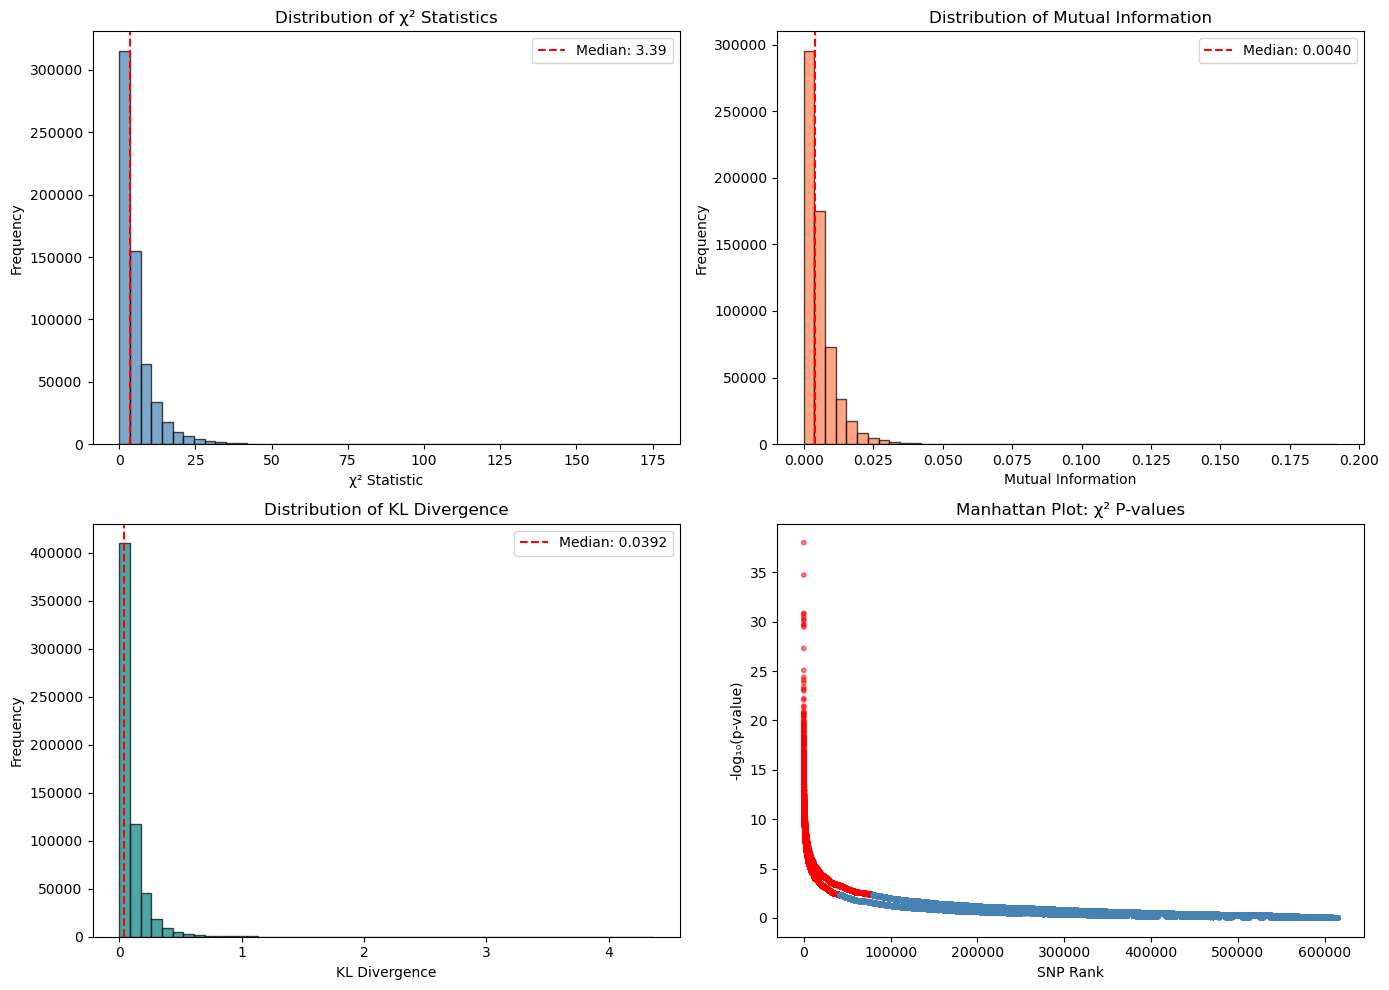

In [13]:
# Visualization panel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: χ² distribution
ax = axes[0, 0]
ax.hist(results_df['chi2'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(results_df['chi2'].median(), color='red', linestyle='--', 
           label=f'Median: {results_df["chi2"].median():.2f}')
ax.set_xlabel('χ² Statistic')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of χ² Statistics')
ax.legend()

# Plot 2: MI distribution
ax = axes[0, 1]
ax.hist(results_df['mutual_information'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(results_df['mutual_information'].median(), color='red', linestyle='--',
           label=f'Median: {results_df["mutual_information"].median():.4f}')
ax.set_xlabel('Mutual Information')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mutual Information')
ax.legend()

# Plot 3: KL divergence distribution
ax = axes[1, 0]
ax.hist(results_df['kl_divergence'].dropna(), bins=50, color='teal', edgecolor='black', alpha=0.7)
ax.axvline(results_df['kl_divergence'].median(), color='red', linestyle='--',
           label=f'Median: {results_df["kl_divergence"].median():.4f}')
ax.set_xlabel('KL Divergence')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of KL Divergence')
ax.legend()

# Plot 4: -log10(p-value) Manhattan-style
ax = axes[1, 1]
log_p = -np.log10(results_df['chi2_pvalue'].clip(lower=1e-300))
sorted_df = results_df.sort_values('chi2', ascending=False).reset_index(drop=True)
colors = ['red' if sig else 'steelblue' for sig in sorted_df['chi2_significant_fdr']]
ax.scatter(range(len(sorted_df)), -np.log10(sorted_df['chi2_pvalue'].clip(lower=1e-300)),
           c=colors, alpha=0.5, s=10)
ax.set_xlabel('SNP Rank')
ax.set_ylabel('-log₁₀(p-value)')
ax.set_title('Manhattan Plot: χ² P-values')

plt.tight_layout()
plt.show()

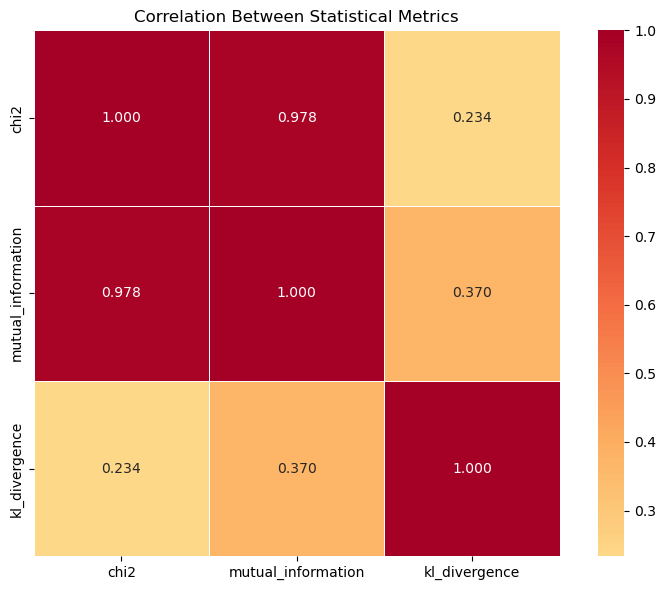

In [14]:
# Correlation heatmap
metric_cols = ['chi2', 'mutual_information', 'kl_divergence']
corr_matrix = results_df[metric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Between Statistical Metrics')
plt.tight_layout()
plt.show()

## Step 7: Select Top SNPs and Create Ranking

In [15]:
# Create composite ranking
results_df['rank_chi2'] = results_df['chi2'].rank(ascending=False)
results_df['rank_mi'] = results_df['mutual_information'].rank(ascending=False)
results_df['rank_kl'] = results_df['kl_divergence'].rank(ascending=False)

# Average rank (lower is better)
results_df['composite_rank'] = (results_df['rank_chi2'] + results_df['rank_mi'] + 
                                 results_df['rank_kl']) / 3

# Add consensus count column
results_df['tests_passed'] = results_df['snp_id'].apply(lambda x: snp_counts.get(x, 0))

# Filter for SNPs that passed ALL 3 tests
results_df_all3 = results_df[results_df['tests_passed'] == 3].copy()
results_df_all3_sorted = results_df_all3.sort_values('composite_rank')

# Also keep full sorted results for reference
results_df_sorted = results_df.sort_values('composite_rank')

print(f"SNPs passing ALL 3 tests: {len(results_df_all3_sorted)}")
print(f"\nTop 25 SNPs (All 3 Tests Passed):")
print("="*80)
display(results_df_all3_sorted[['snp_id', 'chi2', 'mutual_information',
                                 'kl_divergence', 'composite_rank', 'tests_passed']].head(25))

SNPs passing ALL 3 tests: 30

Top 25 SNPs (All 3 Tests Passed):


,snp_id,chi2,mutual_information,kl_divergence,composite_rank,tests_passed
147137,"4:17813761[b37]G,A",175.081948,0.192157,3.878612,1.333333,3
4028,"1:12387655[b37]G,A",159.962062,0.173566,3.868477,2.333333,3
190536,"5:41181491[b37]G,T",142.028434,0.155135,3.279970,5.000000,3
473430,"14:96938945[b37]A,T",138.716937,0.160640,2.856275,6.666667,3
398403,"11:112053732[b37]T,A",102.375000,0.118875,2.152359,18.333333,3
33829,"1:168205652[b37]G,A",96.518313,0.104790,2.405698,19.666667,3
285039,"7:156743124[b37]G,T",75.676494,0.086756,3.234560,57.666667,3
578517,"20:5547557[b37]A,T",76.601112,0.085464,1.724905,73.333333,3
19354,"1:79095386[b37]A,T",76.392625,0.088950,1.626169,82.000000,3
509646,"16:55844911[b37]G,A",69.257416,0.075885,1.667802,126.000000,3


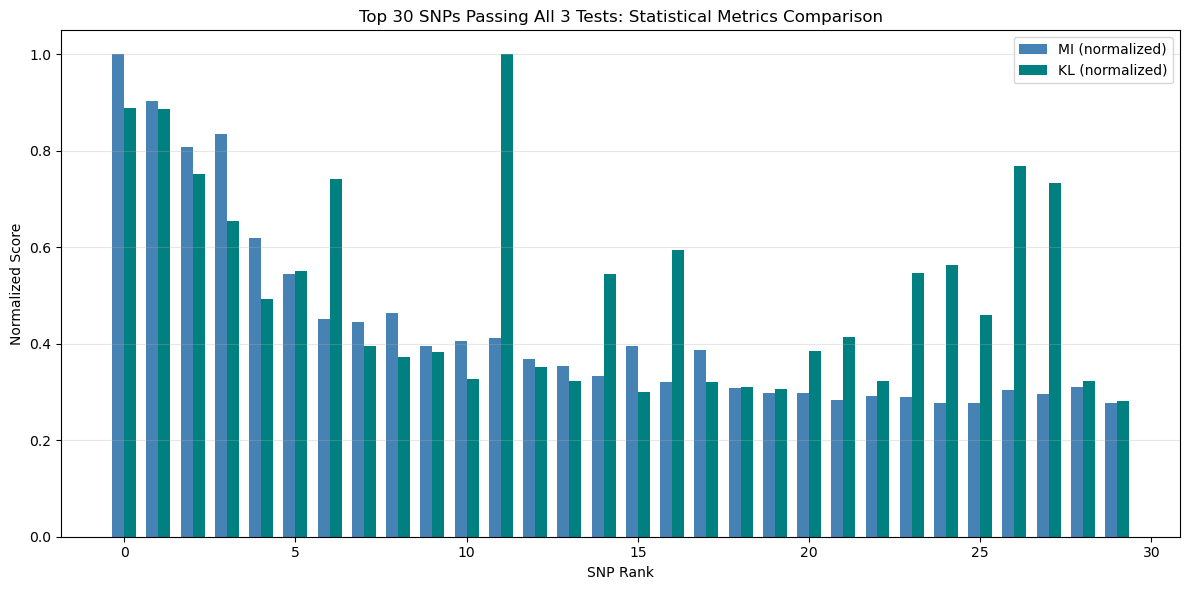


Total SNPs passing all 3 tests: 30


In [16]:
# Top SNPs visualization (using SNPs that passed all 3 tests)
fig, ax = plt.subplots(figsize=(12, 6))

top_snps = results_df_all3_sorted
n_display = min(50, len(top_snps))
x = np.arange(n_display)

if len(top_snps) > 0:
    # Normalize metrics for comparison
    mi_norm = top_snps['mutual_information'].head(n_display) / top_snps['mutual_information'].max()
    kl_norm = top_snps['kl_divergence'].head(n_display) / top_snps['kl_divergence'].max()

    width = 0.35
    ax.bar(x - width/2, mi_norm, width, label='MI (normalized)', color='steelblue')
    ax.bar(x + width/2, kl_norm, width, label='KL (normalized)', color='teal')

    ax.set_xlabel('SNP Rank')
    ax.set_ylabel('Normalized Score')
    ax.set_title(f'Top {n_display} SNPs Passing All 3 Tests: Statistical Metrics Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, 'No SNPs passed all 3 tests', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('No SNPs Passed All 3 Tests')

plt.tight_layout()
plt.show()

print(f"\nTotal SNPs passing all 3 tests: {len(results_df_all3_sorted)}")

## Step 8: Save Results

In [17]:
# Save full results
output_path = str(PATHS.OUTPUT_DIR / "statistical_snp_scores_02b.csv")
results_df_sorted.to_csv(output_path, index=False)
print(f"Full results saved: {output_path}")

# Save SNPs that passed ALL 3 tests (primary output)
all3_snps_path = str(PATHS.OUTPUT_DIR / "statistical_all3_snps_02b.csv")
results_df_all3_sorted.to_csv(all3_snps_path, index=False)
print(f"SNPs passing all 3 tests saved: {all3_snps_path} ({len(results_df_all3_sorted)} SNPs)")

# Save SNP IDs only (for PLINK extraction) - using all 3 tests filter
all3_ids_path = str(PATHS.OUTPUT_DIR / "statistical_all3_snp_ids_02b.txt")
results_df_all3_sorted[['snp_id']].to_csv(all3_ids_path, index=False, header=False)
print(f"All-3-tests SNP IDs saved: {all3_ids_path}")

# Save alias for downstream notebooks expecting "all4" name
all4_snps_path = str(PATHS.OUTPUT_DIR / "statistical_all4_snps_02b.csv")
results_df_all3_sorted.to_csv(all4_snps_path, index=False)
print(f"Alias saved: {all4_snps_path}")

# Also save top N for backward compatibility
top_n = SITUATIONAL_FILTERS.FST_TOP_N
top_snps_df = results_df_sorted.head(top_n)
top_snps_path = str(PATHS.OUTPUT_DIR / "statistical_top_snps_02b.csv")
top_snps_df.to_csv(top_snps_path, index=False)
print(f"Top {top_n} SNPs (by rank) saved: {top_snps_path}")

top_ids_path = str(PATHS.OUTPUT_DIR / "statistical_top_snp_ids_02b.txt")
top_snps_df[['snp_id']].to_csv(top_ids_path, index=False, header=False)
print(f"Top {top_n} SNP IDs saved: {top_ids_path}")

# Save ML data with ONLY all-3-tests SNPs (memory efficient for downstream ML)
all3_snp_ids = results_df_all3_sorted['snp_id'].tolist()
available_all3_snps = [s for s in all3_snp_ids if s in genotype_df.columns]
ml_cols = ['sample', 'pop'] + available_all3_snps
ml_data_all3 = genotype_df[ml_cols]

ml_data_path = str(PATHS.OUTPUT_DIR / "statistical_ml_data_02b.csv")
ml_data_all3.to_csv(ml_data_path, index=False)
print(f"ML data (all-3-tests SNPs only) saved: {ml_data_path}")
print(f"  → {len(available_all3_snps)} SNPs, {len(ml_data_all3)} samples")

Full results saved: data/1000genomes/output_sea_jpt_cn/statistical_snp_scores_02b.csv
SNPs passing all 3 tests saved: data/1000genomes/output_sea_jpt_cn/statistical_all3_snps_02b.csv (30 SNPs)
All-3-tests SNP IDs saved: data/1000genomes/output_sea_jpt_cn/statistical_all3_snp_ids_02b.txt
Top 1000 SNPs (by rank) saved: data/1000genomes/output_sea_jpt_cn/statistical_top_snps_02b.csv
Top 1000 SNP IDs saved: data/1000genomes/output_sea_jpt_cn/statistical_top_snp_ids_02b.txt
ML data (all-3-tests SNPs only) saved: data/1000genomes/output_sea_jpt_cn/statistical_ml_data_02b.csv
  → 30 SNPs, 504 samples


In [18]:
# Cleanup temp VCF
import os
temp_vcf = f"{vcf_output}.vcf"
temp_log = f"{vcf_output}.log"

if os.path.exists(temp_vcf):
    os.remove(temp_vcf)
    print(f"Removed: {temp_vcf}")
if os.path.exists(temp_log):
    os.remove(temp_log)
    print(f"Removed: {temp_log}")

Removed: data/1000genomes/output_sea_jpt_cn/statistical_analysis_temp.vcf
Removed: data/1000genomes/output_sea_jpt_cn/statistical_analysis_temp.log


## Summary

In [19]:
print("="*70)
print("STATISTICAL SNP SELECTION SUMMARY")
print("="*70)

print(f"\nInput:")
print(f"  Pfile: {INPUT_PFILE}")
print(f"  Samples: {len(genotype_df)}")
print(f"  SNPs analyzed: {len(snp_columns)}")
print(f"  Populations: {list(populations.unique())}")

print(f"\nStatistical Tests:")
print(f"  1. Pearson χ² test (FDR corrected)")
print(f"  2. Mutual Information (top 500)")
print(f"  3. KL Divergence (top 500)")

print(f"\nFiltering Results:")
print(f"  χ² FDR significant: {results_df['chi2_significant_fdr'].sum()}")
print(f"  Consensus (≥2 tests): {len(snps_in_2)}")
print(f"  ★ Passed ALL 3 tests: {len(snps_in_3)}")

if len(results_df_all3_sorted) > 0:
    print(f"\nTop SNP (All 3 Tests):")
    top = results_df_all3_sorted.iloc[0]
    print(f"  {top['snp_id']}")
    print(f"  χ²: {top['chi2']:.2f}, MI: {top['mutual_information']:.4f}, KL: {top['kl_divergence']:.4f}")

print(f"\nOutput Files:")
print(f"  - statistical_snp_scores_02b.csv (all results)")
print(f"  - statistical_all3_snps_02b.csv ({len(results_df_all3_sorted)} SNPs passing all 3 tests) ★")
print(f"  - statistical_all3_snp_ids_02b.txt (IDs for PLINK extraction) ★")
print(f"  - statistical_top_snps_02b.csv (top {top_n} by composite rank)")
print(f"  - statistical_ml_data_02b.csv (genotype matrix)")

print(f"\nNext Steps:")
print(f"  Option A: Run 03_fst_and_pca.ipynb (FST-based selection)")
print(f"  Option B: Run 04_ml_training.ipynb with all-4-tests SNPs")
print(f"  Option C: Compare both methods in 04b_ml_training_statistical.ipynb")

STATISTICAL SNP SELECTION SUMMARY

Input:
  Pfile: data/1000genomes/output_sea_jpt_cn/SEA_JPT_CN_FINAL_DATA_FOR_FST
  Samples: 504
  SNPs analyzed: 614759
  Populations: ['CN', 'SEA', 'JPT']

Statistical Tests:
  1. Pearson χ² test (FDR corrected)
  2. Mutual Information (top 500)
  3. KL Divergence (top 500)

Filtering Results:
  χ² FDR significant: 62804
  Consensus (≥2 tests): 932
  ★ Passed ALL 3 tests: 30

Top SNP (All 3 Tests):
  4:17813761[b37]G,A
  χ²: 175.08, MI: 0.1922, KL: 3.8786

Output Files:
  - statistical_snp_scores_02b.csv (all results)
  - statistical_all3_snps_02b.csv (30 SNPs passing all 3 tests) ★
  - statistical_all3_snp_ids_02b.txt (IDs for PLINK extraction) ★
  - statistical_top_snps_02b.csv (top 1000 by composite rank)
  - statistical_ml_data_02b.csv (genotype matrix)

Next Steps:
  Option A: Run 03_fst_and_pca.ipynb (FST-based selection)
  Option B: Run 04_ml_training.ipynb with all-4-tests SNPs
  Option C: Compare both methods in 04b_ml_training_statistical.i